In [1]:
import pandas as pd
import os
from dotenv import load_dotenv
import json
import spacy
import random
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

import pickle

In [2]:
load_dotenv()

VAL_DATA = pd.read_csv('VAL_DATA.csv')
TRAIN_DATA = pd.read_csv('TRAIN_DATA.csv')
DATA = pd.read_csv(os.getenv("LABELED_DATA_PATH"))

RANDOM_SEED = 42

Для каждого класса рассмотрим валидационную и тренировную выборку, а после внесения изменений будет отслеживать улучшения метрики переобучением прокси модельки.
В качетсве нее возьмем простой baseline, где будут сравнивать метрики в разрезах рассматриваемых классов.

In [3]:
def train_proxy_model_and_report(train_data, val_data):
    X_train, y_train = train_data['text'], train_data['sentiment']
    X_test, y_test = val_data['text'], val_data['sentiment']

    pipeline = Pipeline(
        [
            ("tfidf", TfidfVectorizer()),
            ("clf", LogisticRegression(random_state=RANDOM_SEED, max_iter=100)),
        ]
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(classification_report(y_test, y_pred))

In [4]:
# зафиксируем изначальные метрики

train_proxy_model_and_report(TRAIN_DATA, VAL_DATA)

              precision    recall  f1-score   support

    external       0.77      0.75      0.76      2164
  harassment       0.28      0.57      0.38        44
      normal       0.93      0.94      0.93      8000
        spam       0.44      0.45      0.45       110
      threat       0.80      0.44      0.57       102

    accuracy                           0.88     10420
   macro avg       0.65      0.63      0.62     10420
weighted avg       0.89      0.88      0.88     10420



Сильно выделяются метрики для классов `spam` и `harassment`. Что для baseline, что для более сильных моделей, полученных в ноутбуке `/model/train_model` эти классы хуже всего отлавливаются моделькой.

# Spam

Рассмотрим матрицу ошибок для одной из лучших моделей

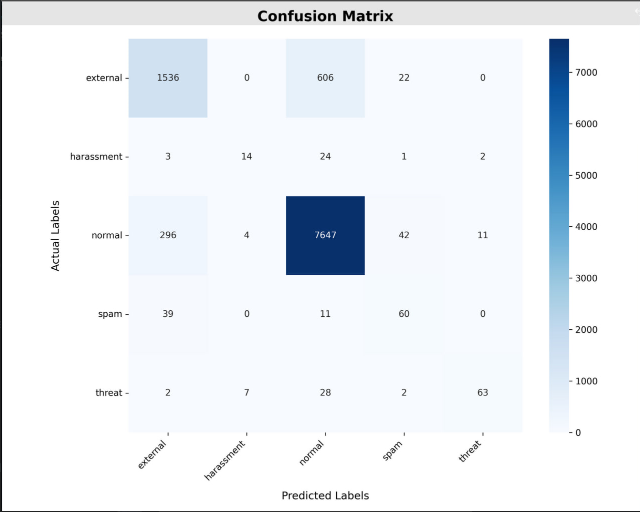

Видно, что модель примерно в 15 процентах случаев путает `spam` и `external`. Также модель часто путает класс `normal` и `spam`. Рассмотрим эти примеры.

In [5]:
with open("model.pkl", "rb") as f:
    best_model = pickle.load(f)
y_pred = best_model.predict(VAL_DATA["text"])
errors = VAL_DATA.copy()
errors["pred"] = y_pred

In [6]:
spam_fp = errors[
    (errors["pred"] == "spam")
    & (errors["sentiment"].isin(["normal", "external"]))
]

In [7]:
# рассмотрим нормальные сообщения, отмеченные как спам

normal_as_spam = spam_fp[spam_fp["sentiment"] == "normal"]
normal_as_spam.sample(5)

,Unnamed: 0,text,item_title,sentiment,synthetic,pred
4081,309029,Подробности обсудите с шеф-поваром.,Пoвар шведской линии,normal,0,spam
7614,171567,24 вольта,"Компрессор кондиционера, рефрижератора",normal,0,spam
8277,232704,От леворульной или праворульной?,Шланг Гур высокого давления Ниссан Тиана 31,normal,0,spam
3142,195284,Корзина для фритюрницы 325х225х90 мм,Фритюрница,normal,0,spam
5032,135837,"Работаю я быстро , 1,5-2 часа",Наращивание ресниц,normal,0,spam


In [8]:
# рассмотрим external сообщения, отмеченные как спам

external_as_spam = spam_fp[spam_fp["sentiment"] == "external"]
external_as_spam.sample(5)

,Unnamed: 0,text,item_title,sentiment,synthetic,pred
1341,360982,"Князь, здравствуйте! Вам актуален заказ шикарн...",Адресник на дом и дачу,external,0,spam
1914,358839,босоножки наш телеграм канал\n\nbaby наш чат \...,Туры по Удмуртии и России,external,0,spam
942,360529,Требуются грузчики и разнорабочие. \nРабота в ...,Грузчик разнорабочий с ежедневной оплатой,external,0,spam
345,360678,"Добрый день, меня зовут Виталий, менеджер комп...",Водитель погрузчика на склад Вахта с проживанием,external,0,spam
1105,361419,"Иван, здравствуйте! Вам актуален заказ шикарно...",Адресники на дом и дачу / таблички,external,0,spam


В ходе рассмотрения этих данных, выявлено следующее:

1. Модель триггерится на упоминания денег даже в обычных сообщения. Это происходит потому, что в спам открытых датасетах часто содержит способы их заработать.
2. Почти во всех спам сообщениях есть ссылки на сторонние мессенджеры или их упоминание.

Связи с этим решено слить `spam` в класс `external`, так как классы трудно отличимы лишь по тексту сообщений для созданных моделей, спам следует отличать от `external` введением дополнительного трекинга частоты отправки сообщения одним пользователем. Также для бизнеса почти каждое спам сообщение является малоотличимым от перевода в другой мессенджер.

# Harassment and threat

In [9]:
harassment_fp = errors[
    (errors["pred"] == "harassment")
    & (errors["sentiment"].isin(["normal", "threat"]))
]

In [10]:
# рассмотрим нормальные сообщения, отмеченные как harassment

normal_as_harassment = harassment_fp[harassment_fp["sentiment"] == "normal"]
normal_as_harassment.sample(4)

,Unnamed: 0,text,item_title,sentiment,synthetic,pred
2611,28452,А ты че на балконе сидишь куришь,"Hyundai Solaris 1.6 MT, 2013, 198 000 км",normal,0,harassment
6782,219690,Ты с Праги ?,"Тректоп на руках,46-52",normal,0,harassment
8041,60439,Ты знаешь кто я,Квадроцикл Bashan 150cm,normal,0,harassment
7225,279857,Работали с таким самокатом?,Ремонт электросамокатов и гироскутеров,normal,0,harassment


In [11]:
# рассмотрим threat сообщения, отмеченные как harassment

threat_as_harassment = harassment_fp[harassment_fp["sentiment"] == "threat"]
threat_as_harassment.sample(7)

,Unnamed: 0,text,item_title,sentiment,synthetic,pred
10417,367680,пидоры! вам гореть в аду !!!! твари без хребет...,no_item,threat,1,harassment
10328,367459,"тварь, которая покалечила котика, будешь горет...",no_item,threat,1,harassment
10335,367848,порезать тебя тварь ебучую в костроме пацанам ...,no_item,threat,1,harassment
10320,367846,"ты натуральный козел, я тебя гниду пархатую ли...",no_item,threat,1,harassment
10339,367773,"дебилы конченные,перестрелял их всех до одного...",no_item,threat,1,harassment
10332,367513,"тебя кого ипёт ??? никто ничего не сливал, это...",no_item,threat,1,harassment
10336,367887,уничтожить тварь твариную,no_item,threat,1,harassment


In [12]:
# рассмотрим harassment сообщения, отмеченные как normal

normal_fp = errors[
    (errors["pred"] == "normal")
    & (errors["sentiment"].isin(["harassment"]))
]

normal_fp.sample(5)

,Unnamed: 0,text,item_title,sentiment,synthetic,pred
2188,355828,отсасывать мне будешь за эти 4500,"iPhone X, 64 ГБ",harassment,0,normal
2184,355967,"Да в принципе и так по хер\nЗабирай за 30, баб...",Рельсы r17,harassment,0,normal
2178,361096,Бля так и знал что обманешь но будь здарова ),Скин кс го 2,harassment,0,normal
2170,355964,Идите на хуй,Подгузники,harassment,0,normal
2203,359701,Там она хуйня,Marcelo miracles пуховик,harassment,0,normal


Большинство таких сообщений просто содержат мат, но не детектируются моделью. Это происходит потому, что в открытых датасетах классом `harassment` чаще называются именно прямые оскорбления, в то время как
на платформе Авито сюда включены и просто матосодержащие сообщения, так как они тоже нежалетельны. Чтобы решить это проблему, можно добавить в случайных сэмпл тренировочных данных матерные выражения и пометить их как `harassment`, добавив в качестве агументации редкие опечатки. Это должно повысить качество на таких примерах.

# Extend and reorganize dataset

Первый шаг - слить `spam` и `harassment`. Удаляем из тренировочного датасета `spam` из открытых источников, а весь оставшийся - переопределяем как `external`

In [13]:
# удаляем спам из открытых источников
new_train_data = TRAIN_DATA[~((TRAIN_DATA['sentiment'] == 'spam') & (TRAIN_DATA['synthetic'] == 1))]

# оставшийся спам переводим в external
new_train_data.loc[TRAIN_DATA['sentiment'] == 'spam', 'sentiment'] = 'external'
new_train_data = new_train_data.dropna()

# аналогично с валидационной выборкой
new_val_data = VAL_DATA[~((VAL_DATA['sentiment'] == 'spam') & (VAL_DATA['synthetic'] == 1))]
new_val_data.loc[VAL_DATA['sentiment'] == 'spam', 'sentiment'] = 'external'
new_val_data = new_val_data.dropna()

In [14]:
# проверяем что нет спама теперь
new_train_data['sentiment'].unique(), new_val_data['sentiment'].unique()

(array(['normal', 'harassment', 'threat', 'external'], dtype=object),
 array(['external', 'harassment', 'threat', 'normal'], dtype=object))

На основе вот этого списка - https://raw.githubusercontent.com/bars38/Russian_ban_words/master/words.txt был сформирован `bag_words.json`, куда были отобраны самые популярные оскорбления и выражения, а также профильтрованы от корреткных медицинских терминов. Также в json есть три поля:
1. **empty_words** - наши матерные междометия, которые можно вставить в любое место в предложении
2. **verbs** - наши универсальные матерные глаголы
3. **aliases** - оскорбительные обращения

In [39]:
# открываем этот json
with open('bad_words.json') as f:
    bad_words = json.loads(f.read())

# 
nlp = spacy.load("ru_core_news_sm")

In [32]:
def sentence_to_pos_dict(sentence: str) -> dict:
    """
    Функция принимает на вход предложение и возвращает словарь, где ключом является часть речи, а значением - само слово
    """
    doc = nlp(sentence)
    result = {}
    pos_counts = {}
    
    for token in doc:
        if token.pos_ not in ["SPACE"]:
            pos = token.pos_
            pos_counts[pos] = pos_counts.get(pos, 0) + 1
            key = f"{pos}_{pos_counts[pos]}"
            result[key] = token.text
            
    return result

def rebuild_sentence(pos_dict: dict) -> str:
    """
    Восстановление предложения из слова частей речи
    """
    return " ".join(pos_dict.values())

print(sentence_to_pos_dict("Умный кот быстро поймал серую мышь, тут еще что-то красивое"))
print(rebuild_sentence(sentence_to_pos_dict("Умный кот быстро поймал серую мышь, тут еще что-то")))

{'ADJ_1': 'Умный', 'NOUN_1': 'кот', 'ADV_1': 'быстро', 'VERB_1': 'поймал', 'ADJ_2': 'серую', 'NOUN_2': 'мышь', 'PUNCT_1': ',', 'ADV_2': 'тут', 'ADV_3': 'еще', 'PRON_1': 'что', 'PRON_2': '-', 'PRON_3': 'то', 'ADJ_3': 'красивое'}
Умный кот быстро поймал серую мышь , тут еще что - то


In [33]:
def replace_verb(sentence: str) -> str:
    pos_dict = sentence_to_pos_dict(sentence)
    verb_keys = [k for k in pos_dict.keys() if k.startswith("VERB")]

    if not verb_keys:
        return sentence

    key = random.choice(verb_keys)
    pos_dict[key] = random.choice(bad_words["verbs"])
    return rebuild_sentence(pos_dict)

def replace_adj(sentence: str) -> str:
    pos_dict = sentence_to_pos_dict(sentence)
    verb_keys = [k for k in pos_dict.keys() if k.startswith("ADJ")]

    if not verb_keys:
        return sentence

    key = random.choice(verb_keys)
    pos_dict[key] = random.choice(bad_words["adjectives"])
    return rebuild_sentence(pos_dict)


def add_alias(sentence: str) -> str:
    pos_dict = sentence_to_pos_dict(sentence)

    if not pos_dict:
        return sentence

    new_key = f"ALIAS_{random.randint(1, 10**9)}"
    pos_dict[new_key] = random.choice(bad_words["aliases"])
    return rebuild_sentence(pos_dict)


def insert_empty_bad_words(sentence: str) -> str:
    pos_dict = sentence_to_pos_dict(sentence)
    items = list(pos_dict.items())
    insert_pos = random.randint(0, len(items))
    items.insert(
        insert_pos,
        (
            f"EMPTY_{random.randint(1, 10**9)}",
            random.choice(bad_words["empty_words"])
        )
    )
    pos_dict = dict(items)
    return rebuild_sentence(pos_dict)

In [47]:
def random_augmentation(sentence: str) -> str:
    way = np.random.choice([insert_empty_bad_words, add_alias, replace_verb, replace_adj], p=[0.5, 0.35, 0.05, 0.1])
    return way(sentence)

random_augmentation('Добрый день , оплатил жду отправки.')

'Добрый на пизду день , оплатил жду отправки .'

In [46]:
# берем 1000 сообщений класса normal
random_idx_to_augment = new_train_data.loc[new_train_data["sentiment"] == "normal"].sample(n=1000, random_state=RANDOM_SEED).index

# применяем рандомные аугментации
new_train_data.loc[random_idx_to_augment, "text"] = (new_train_data.loc[random_idx_to_augment, "text"].apply(random_augmentation))

# меняем поле synthetic на 2, так как данные уже не совсем реальные. также меняем класс на harassment
# делаем метку synthetic = 2, а не 1, чтобы отличить от прежнего датасета
new_train_data.loc[random_idx_to_augment, "synthetic"] = 2
new_train_data.loc[random_idx_to_augment, "sentiment"] = 'harassment'

In [48]:
new_train_data[['sentiment', 'synthetic']].value_counts()

sentiment   synthetic
normal      0            6000
external    1            3675
            0            2273
harassment  2            2000
            1            1653
threat      1             462
harassment  0              43
threat      0               2
Name: count, dtype: int64

In [49]:
new_val_data[['sentiment', 'synthetic']].value_counts()

sentiment   synthetic
normal      0            8000
external    0            2274
threat      1             100
harassment  0              44
threat      0               2
Name: count, dtype: int64

In [25]:
train_proxy_model_and_report(new_train_data, new_val_data)

              precision    recall  f1-score   support

    external       0.77      0.78      0.78      2274
  harassment       0.26      0.59      0.36        44
      normal       0.93      0.93      0.93      8000
      threat       0.77      0.43      0.55       102

    accuracy                           0.89     10420
   macro avg       0.68      0.68      0.66     10420
weighted avg       0.89      0.89      0.89     10420



In [50]:
# попробуем удалить старые синтетические данные из класса harasment (они имеют после synthetic = 1)
train_proxy_model_and_report(new_train_data[~((new_train_data['sentiment'] == 'harassment') & (new_train_data['synthetic'] == 1))], new_val_data)

              precision    recall  f1-score   support

    external       0.75      0.79      0.77      2274
  harassment       0.83      0.57      0.68        44
      normal       0.93      0.92      0.93      8000
      threat       0.78      0.63      0.70       102

    accuracy                           0.89     10420
   macro avg       0.82      0.73      0.77     10420
weighted avg       0.89      0.89      0.89     10420



In [51]:
# сохраняем новый трейн и тест
only_new_harassment = new_train_data[~((new_train_data['sentiment'] == 'harassment') & (new_train_data['synthetic'] == 1))]
only_new_harassment.to_csv('new_train_data.csv')
new_val_data.to_csv('new_val_data.csv')